# Items Prediction Process

### Imports

In [1]:
from elasticsearch import Elasticsearch
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import keras
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Dense, Masking, GRU, LSTM, Dropout
from keras.callbacks import EarlyStopping
import pandas as pd
import numpy as np
import datetime
import time
import pickle
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

Using TensorFlow backend.


### Functions

#### Get the data from ES and create a pandas dataframe

In [2]:
def es_to_df(start, end, s_rate, tier, host, port):
    """
    Returns data from ES based on the given time period and tier.
    Transforms and downsamples the data into a pandas dataframe.
    
    Parameters:
    start (str): start date in format "yyyy-MM-dd"
    end (str): end date in format "yyyy-MM-dd"
    s_rate (int): the sample rate, each nth entry is taken 
    tier (str): name of the queue (tier) e.g. 'pic'
    host (str): name of the host e.g. 'localhost'
    port (int): number of port e.g. 9200
    
    Returns:
    pd.DataFrame: pandas DataFrame
    
    Example:
    es_timerange("2020-06-01", "2020-06-10", 10, 'pic', 'localhost', 9200)
    """
    
    # Establish connection
    es = Elasticsearch([host], port=port) 
    
    # Create a list of the given dates between start date and end date
    slist = start.split("-")
    slist = map(int, slist)
    slist = list(slist)

    elist = end.split("-")
    elist = map(int, elist)
    elist = list(elist)

    sdate = datetime.date(slist[0], slist[1], slist[2])
    edate = datetime.date(elist[0], elist[1], elist[2])
    delta = edate - sdate

    datelist = list()
    
    for i in range(delta.days + 1):
        day = sdate + datetime.timedelta(days=i)
        datelist.append(day)

    
    # Get the matching data for each day and store it in a list
    final_data = list()
    
    for date in datelist:
        res = es.search(index="queues", body={"query": {
            "bool": {
                                              "must": [
                                                  {"match": {
                                                      "name": "products"}},
                                                  {"match": {
                                                      "tier": tier}},
                                                  {"range": {
                                                      "timestamp": {
                                                          "gte": str(date),
                                                          "lte": str(date),
                                                          "format": "yyyy-MM-dd"
                                                      }
                                                  }
                                                  }
                                              ]
                                              }
        }
        }, size=1440)  # defined size of 1440 entries per day
        daily_data = [elem['_source'] for elem in res['hits']['hits']]
        final_data.extend(daily_data)

    # Create pandas dataframe from final_data list
    df = pd.DataFrame(final_data)
    
    # Downsample the entries
    df = df.iloc[::s_rate, :].copy()  # take every nth entry
    # Format the timestamp
    df.index = df["timestamp"]
    df.index = pd.to_datetime(df.index, format='%Y-%m-%dT%H:%M:%S.%f%z').sort_values()
    df.drop(columns=['timestamp', 'name'], inplace=True)  # drop unnecassry columns
    # Create a list of the items
    df['items'] = [[str(x)] if len(str(x)) < 10 else str(x).split(" ")
                   for x in df['items']]  # convert items to list
    # Change datatype of size
    df['size'] = pd.to_numeric(df['size'])
    
    return df

In [3]:
df_pic = es_to_df("2020-06-08","2020-06-12", 10, "pic", 'localhost', 9200)
df_cen = es_to_df("2020-06-08","2020-06-12", 10, "censhare", 'localhost', 9200)

#### Create the feature enriched dataset for each item

In [4]:
def create_dataset_train(df_pic, df_cen):
    """Adds features to the dataframe and returns the prepared dataset containing
    the sample items and the matching target variables
    
    Parameters:
    df_pic (pd.DataFrame): dataframe containing entries of the pic queue
    df_cen (pd.DataFrame): dataframe containing entries of the censhare queue
    
    Returns:
    data_x (list): list containing the selected sample items
    data_y (list): list containing the target sequences
    """

    # Create a multi label binarized dataframe
    mlb = MultiLabelBinarizer()
    df_cen_mlb = pd.DataFrame(mlb.fit_transform(df_cen['items']), columns=mlb.classes_)
    df_pic_mlb = pd.DataFrame(mlb.fit_transform(df_pic['items']), columns=mlb.classes_)

    # Add features: "n_added_items", "n_removed_items"
    lists = df_pic['items'].tolist()
    current = lists[0]
    diff_sets = [[]]
    diff_sets_rev = [[]]
    for next_list in lists[1:]:
        diff_sets.append(sorted(set(current).difference(set(next_list))))
        diff_sets_rev.append(sorted(set(next_list).difference(set(current))))
        current = next_list

    df_pic['diff_items'] = diff_sets
    df_pic['diff_items_rev'] = diff_sets_rev
    df_pic['n_removed_items'] = df_pic['diff_items'].apply(lambda x: len(x))
    df_pic['n_added_items'] = df_pic['diff_items_rev'].apply(lambda x: len(x))

    # Get only the values from each column
    sizes_pic = df_pic['size'].values
    added_pic = df_pic['n_added_items'].values
    removed_pic = df_pic['n_removed_items'].values
    
    # Cummulate multi label binarized dataframe
    df_pic_cumsum = df_pic_mlb.cumsum()
    df_pic_cumsum_rev = df_pic_mlb.iloc[::-1].cumsum().iloc[::-1]
    
    # Exclude items which are already in the queue and haven´t left at the last timestamp
    exclude_first = df_pic['items'][0]
    exclude_last = df_pic['items'][-1]

    data_x = list()
    data_y = list()

    # Create each sample
    for item in df_cen_mlb.columns: #first queue
        if ((item in df_pic_mlb.columns) and (item not in exclude_first and item not in exclude_last)):

            # Mask the occurence of the item in both queues
            mask_cen = df_cen_mlb[item] != 0
            mask_pic = df_pic_mlb[item] != 0

            # Get the position it appears in the first queue and the first and last time in the second queue
            position_cen = df_cen_mlb[item][mask_cen].index[0]
            position_pic = df_pic_mlb[item][mask_pic].index[-1]
            position_pic_first = df_pic_mlb[item][mask_pic].index[0]

            # Filter out odd behaviour (if it first appears in the second and afterwards in the first)
            # and slice the features based on the positions
            if position_cen > position_pic:
                diff = position_pic - position_pic_first
                size = sizes_pic[position_pic_first:position_pic]
                added = added_pic[position_pic_first:position_pic]
                removed = removed_pic[position_pic_first:position_pic]
            else:
                diff = position_pic - position_cen
                size = sizes_pic[position_cen:position_pic]
                added = added_pic[position_cen:position_pic]
                removed = removed_pic[position_cen:position_pic]

            # Create list of steps it stays in the queue
            steps_list = list(range(1, diff+1))

            # Create a dataframe and fill in the features
            df_item = pd.DataFrame(data=steps_list, columns=[item]).astype(str).astype(int)
            df_item['Q_size'] = size
            df_item['n_added'] = added
            df_item['n_removed'] = removed
            df_item['cen'] = 1 #mark that it appeared in the first queue
            
            # Create target data
            y_item = pd.DataFrame(data=steps_list[::-1], columns=[item])
            mask_y = y_item[item] != 0
            y_item_masked = y_item[item][mask_y]
            
            data_x.append(df_item)
            data_y.append(y_item_masked)

        else:
            continue
            

    for item in df_pic_mlb.columns:
        if ((item not in df_cen_mlb.columns) and (item not in exclude_first and item not in exclude_last)):
            
            mask = df_pic_mlb[item] != 0

            df_item = pd.DataFrame(df_pic_cumsum[item][mask])
            #X_item = X_item.rename(columns = {item: 'n_steps_in_Q'})
            df_item['Q_size'] = sizes_pic[mask]
            df_item['n_added'] = added_pic[mask]
            df_item['n_removed'] = removed_pic[mask]
            df_item['cen'] = 0
            
            y_item = df_pic_cumsum_rev[item][mask]

            data_x.append(df_item)
            data_y.append(y_item)

        else:
            continue
    
    
    return data_x, data_y

In [5]:
X, y = create_dataset_train(df_pic, df_cen)

In [6]:
X[0]

,1002782354,Q_size,n_added,n_removed,cen
0,1,1512,84,359,1
1,2,1621,188,79,1
2,3,1695,74,0,1
3,4,1584,0,111,1
4,5,1496,33,121,1
5,6,1493,24,27,1
6,7,1518,26,1,1
7,8,1516,113,115,1
8,9,1723,324,117,1
9,10,1786,67,4,1


In [7]:
y[0]

0     23
1     22
2     21
3     20
4     19
5     18
6     17
7     16
8     15
9     14
10    13
11    12
12    11
13    10
14     9
15     8
16     7
17     6
18     5
19     4
20     3
21     2
22     1
Name: 1002782354, dtype: int64

#### Padding

In [8]:
maxlen = len(df_pic)

In [9]:
def split_train_test_seq(X, y, **kwargs):
    """ Splits the datasets, after padding the sequences
    to a global length
    
    Parameters:
    X : preprocessed datasets including features
    y : preprocessd datasets with target variable
    
    Returns:
    X_train : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    X_test : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    y_train : target sequences padded with 0 in shape (number of samples, timesteps, features)
    y_test : target sequences padded with 0 in shape (number of samples, timesteps, features)
    """
    # maxlen for padding
    #maxlen = len(df_pic)
    def pad(sequence, maxlen):
        # fills list post (at the end) with 0s to make even sized sequences
        return pad_sequences(sequence, maxlen=maxlen, dtype='float32', padding='post', value=0.0)
    
    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, **kwargs)
    
    #padding 
    X_train = pad([x.values for x in X_train], maxlen)
    X_test = pad([x.values for x in X_test], maxlen)

    #reshape for LSTM
    y_train = pad([y.values for y in y_train], maxlen)
    y_train = [x.reshape(-1,1) for x in y_train]
    y_train = np.asarray(y_train)
    
    y_test = pad([y.values for y in y_test], maxlen)
    y_test = [x.reshape(-1,1) for x in y_test]
    y_test = np.asarray(y_test)
    
    
    # for validation 
    # 0.7 * 0.2 (20% validation data from train)
    # X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.14)
    # X_val = pad([x.values for x in X_val], maxlen)
    # y_val = pad([y.values for y in y_val], maxlen)
    # y_val = [x.reshape(-1,1) for x in y_val]
    # y_val = np.asarray(y_val)
    
    
    #for train_on_batch
    #X_train = [x.reshape(1,-1,5) for x in X_train]
    #X_train = np.asarray(X_train)
    #X_test = [x.reshape(1,-1,5) for x in X_test]
    #X_test = np.asarray(X_test)
    #X_val = [x.reshape(1,-1,5) for x in X_val]
    #X_val = np.asarray(X_val)
    #, X_val, y_val
    #, X_valseq, y_valseq
    #X_valseq.shape, y_valseq.shape
    return X_train, X_test, y_train, y_test

In [10]:
X_train, X_test, y_train, y_test = split_train_test_seq(X, y, test_size=0.3)

In [11]:
def scale(X_train, X_test, y_train, y_test):
    """ Scales the datasets and saves the scaler
    
    Parameters:
    X_train : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    X_test : feature sequences padded with 0 in shape (number of samples, timesteps, features)
    y_train : target sequences padded with 0 in shape (number of samples, timesteps, features)
    y_test : target sequences padded with 0 in shape (number of samples, timesteps, features)    
    
    Returns:
    X_train_scaled : scaled sequences
    X_test_scaled : scaled sequences
    y_train_scaled : scaled sequences
    y_test_scaled : scaled sequences
    """
    
    # Set number of samples, number of timesteps and number of features
    n_sa_tr, n_ts, n_f = X_train.shape
    n_sa_te, n_ts, n_f = X_test.shape
    d_y = 1 # dimension 1 for target variables
    
    # Initiate the scalers
    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    
    # Scale the datasets
    X_train_scaled = scaler_X.fit_transform(X_train.reshape(n_sa_tr*n_ts, n_f)).reshape(X_train.shape)
    X_test_scaled = scaler_X.transform(X_test.reshape(n_sa_te*n_ts, n_f)).reshape(X_test.shape)
    
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(n_sa_tr*n_ts, d_y)).reshape(y_train.shape)
    y_test_scaled = scaler_y.transform(y_test.reshape(n_sa_te*n_ts, d_y)).reshape(y_test.shape)
    
    # Save the scaler
    pickle.dump(scaler_X, open("scaler_x.p","wb"))
    pickle.dump(scaler_y, open("scaler_y.p","wb"))
    
    return X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled

In [12]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = scale(X_train, X_test, y_train, y_test)

In [13]:
def downsample(X_train, X_test, y_train, y_test, rate):
    """ Downsamples the number of items based on given rate
    
    Parameters:
    X_train : feature sequences 
    X_test : feature sequences 
    y_train : target sequences 
    y_test : target sequences 
    rate (float): rate of downsampling e.g. 0.8 means keep 80% of samples
    
    Returns:
    X_train_sampled:
    X_test_sampled:
    y_train_sampled:
    y_test_sampled:
    """
    # Mask random choosen samples based on rate
    mask_train = np.random.choice([False, True], len(X_train), p=[1-rate,rate])
    mask_test = np.random.choice([False, True], len(X_test), p=[1-rate,rate])

    X_train_sampled = X_train[mask_train]
    y_train_sampled = y_train[mask_train]

    X_test_sampled = X_test[mask_test]
    y_test_sampled = y_test[mask_test]
    
    return X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled

In [14]:
X_train_sampled, X_test_sampled, y_train_sampled, y_test_sampled = downsample(X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled, 0.8)

In [15]:
# Build the model
n_steps = X_train_sampled.shape[1] #number of steps
n_features = X_train_sampled.shape[2] #number of features
n_neurons = 20

model = Sequential()
model.add(Masking(mask_value=0.0,input_shape=(n_steps, n_features))) #Masking Layer for padding 
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dropout(0.1))
model.add(LSTM(n_neurons, return_sequences=True))
model.add(Dense(1, input_dim=n_neurons)) #Dense Layer to generate 1Dimensional Outputs
model.compile(loss='mae', optimizer='adam', metrics=['mae'])

# Define CallBacks
early_stop = EarlyStopping(monitor='mae', mode='min', patience=5)

# Start training
history = model.fit(X_train_sampled, y_train_sampled, epochs=5, validation_split=0.2, callbacks=[early_stop])

# Save the model
model.save("model_cen_pic_5epochs.h5")

Train on 5917 samples, validate on 1480 samples
Epoch 1/5
5917/5917 [==============================] - 417s 70ms/step - loss: 0.1447 - mae: 0.1447 - val_loss: 0.1055 - val_mae: 0.1055
Epoch 2/5
5917/5917 [==============================] - 417s 70ms/step - loss: 0.1109 - mae: 0.1109 - val_loss: 0.0944 - val_mae: 0.0944
Epoch 3/5
5917/5917 [==============================] - 416s 70ms/step - loss: 0.1034 - mae: 0.1034 - val_loss: 0.0920 - val_mae: 0.0920
Epoch 4/5
5917/5917 [==============================] - 419s 71ms/step - loss: 0.1021 - mae: 0.1021 - val_loss: 0.0905 - val_mae: 0.0905
Epoch 5/5
5917/5917 [==============================] - 418s 71ms/step - loss: 0.0991 - mae: 0.0991 - val_loss: 0.0889 - val_mae: 0.0889


In [16]:
# Predict and rescale the prediction
pred = model.predict(X_test_sampled)

# Load the scalers used for training
scaler_X = pickle.load(open("scaler_x.p", "rb"))
scaler_y = pickle.load(open("scaler_y.p", "rb"))

pred_rescaled = scaler_y.inverse_transform(pred.reshape(-1, 1)).reshape(pred.shape)
y_target = scaler_y.inverse_transform(y_test_sampled.reshape(-1, 1)).reshape(y_test_sampled.shape)

n_sa_te = X_test_sampled.shape[0] #number of samples test
n_ts_te = X_test_sampled.shape[1] #number of timesteps test
n_fe_te = X_test_sampled.shape[2] #number of features test
X_test_rescaled = scaler_X.inverse_transform(X_test_sampled.reshape(n_sa_te*n_ts_te, n_fe_te)).reshape(X_test_sampled.shape)

# Score the prediction
#mask all entries of X_test, which are not 0 or negative to filter out the padded values
mask = ~np.all((X_test_rescaled.reshape(-1, n_fe_te) <= 1e-4) & (X_test_rescaled.reshape(-1, n_fe_te) >= -1e-4), axis=-1)
mean_absolute_error(y_target.reshape(-1)[mask], pred_rescaled.reshape(-1)[mask])

41.51007

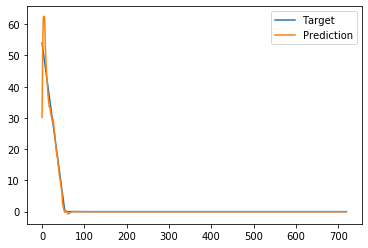

In [17]:
x = np.random.randint(len(y_test_sampled))
plt.plot(y_target[x], label='Target')
plt.plot(pred_rescaled[x], label='Prediction')
plt.legend()
plt.show()
#plt.savefig('foo.png')